# 04 — Learning the equilibrium: model-free households on a real feeder

**Repository:** `stackelberg-dr-real-feeder` · **Milestone 3**

Everything so far assumed **clairvoyant** households: given prices, each solves
its optimization exactly and instantly (eq. 21 of the recreated paper). That
assumption quietly carries three others — the household knows its own utility
*function* (not just how it feels), trusts the math, and reacts with zero delay.
Real prosumers satisfy none of these. This notebook removes the assumption and
asks the question that Milestones 1–2 built the answer key for:

> **Can agents that observe only their own experience find the equilibrium —
> and what do their learning trajectories do to the feeder on the way?**

The three information regimes of this repository:

| Regime | Households | UCs | Where solved |
|---|---|---|---|
| R1 | clairvoyant best response | closed-form linear system | Notebook 02 (exact SE) |
| R2 | clairvoyant best response | Algorithm-2 integral control | Notebooks 02 §6, 03 §4 |
| **R3 (here)** | **bandit learners: own realized comfort only** | Algorithm-2, slower timescale | this notebook |

Because R1 gives the *exact* equilibrium, every learning claim below is measured
against ground truth, not eyeballed — the standing advantage of having recreated
the analytical model first.

**Findings preview:** the learners find the equilibrium (§3) with a genuinely
two-sided tuning landscape (§4: leaders too slow never arrive, too eager chase
noise); but their exploration *flicker permanently eats the voltage margin* the
equilibrium analysis promised (§5), and the same holds under network-aware
prices (§6) — learning agents are always in M2 §4's transient, never at M1's
resting point.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sgdr.plotting import apply_style, PALETTE, savefig
from sgdr import model as M, feeder as F, network_game as NG, learning as L
from sgdr import distributed as D

apply_style()
RESULTS = pathlib.Path("../results/m3"); RESULTS.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

fdr = F.load_feeder()

## §1 · What "learning" means here — and why this learner

**The information diet.** A household in this notebook knows: the posted prices
(public), its own budget (its wallet), and — after consuming — a single number:
how good that felt. It does **not** know $\alpha_n$, $\beta_n$, that its comfort
is logarithmic, who else is on the feeder, or that a Stackelberg game exists.
This is the honest description of a real prosumer: comfort is *experienced*, not
computed from a formula.

**The learner: two-point bandit gradient ascent.** Each trading round the
household probes its habit $x_n$ twice — first half-period slightly above, second
slightly below along a random direction $\Delta$ — feels the comfort difference,
and forms a finite-difference gradient estimate along $\Delta$:

$$\hat g = \frac{U(x + \delta\Delta) - U(x - \delta\Delta)}{2\delta}\,\Delta,
\qquad x \leftarrow \Pi_{\text{budget}}\!\left[x + \eta\,\hat g\right]$$

with the classical decaying schedules $\eta_t \propto 1/\sqrt{t}$,
$\delta_t \propto t^{-1/4}$, and $\Pi$ the Euclidean projection onto the
household's own budget set $\{x \ge 0,\ p\cdot x \le C_n\}$ (it knows its wallet
and the prices — nothing else is needed). A power engineer will recognize the
family: it is **perturb-and-observe**, the same logic as MPPT tracking on a PV
inverter — wiggle, feel, follow the gradient of an unmeasurable curve.

**Why not deep RL?** Because the question is *whether decentralized selfish
learning finds the game's equilibrium*, and the cleanest instrument that isolates
it is the simplest model-free learner with known guarantees for convex problems.
Deep RL would add machinery this question does not need (a deliberate scoping
decision — LEDGER M3-A1; distributed deep RL is the natural next step at
full scale).

**The UCs stay themselves.** Leaders keep M1's Algorithm-2 integral control —
but naturally slower: one price update per $T_{uc}$ rounds, driven by the *mean*
demand metered over the period (which also averages away exploration noise —
LEDGER M3-A3). Two coupled feedback loops on different timescales: an inner
learning loop inside an outer pricing loop. Any engineer who has tuned a cascade
controller knows the design rule — and §4 tests it.

## §2 · Sanity first: one learner against fixed prices

Before coupling 96 learners and 3 adaptive leaders, verify the learner itself:
one household, prices frozen, 3 000 rounds. It must find the same answer as
eq. (21) — which it has never seen:

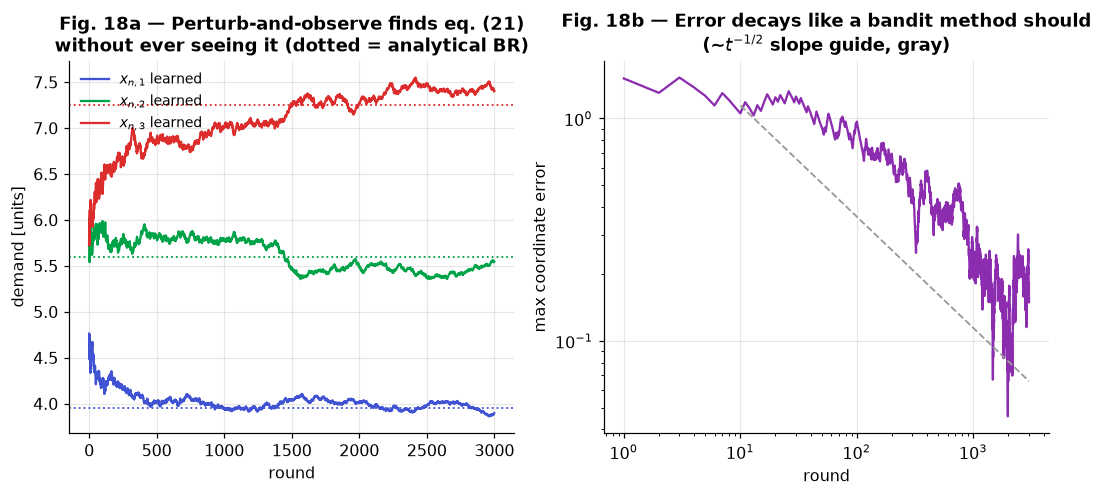

final error 0.1532 on demands of size ~5.6 (2.7%)

In [2]:
g5 = M.paper_base_game(5.0)
y_fixed = np.array([2.0, 1.5, 1.2])
traj, xbr = L.learn_single(g5, n=4, y=y_fixed, n_rounds=3000, seed=1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax = axes[0]
for k in range(3):
    ax.plot(traj[:, k], lw=1.5, color=PALETTE[k], label=f"$x_{{n,{k+1}}}$ learned")
    ax.axhline(xbr[k], color=PALETTE[k], ls=":", lw=1.2)
ax.set_xlabel("round"); ax.set_ylabel("demand [units]")
ax.set_title("Fig. 18a — Perturb-and-observe finds eq. (21)\nwithout ever seeing it (dotted = analytical BR)")
ax.legend(fontsize=9)

ax = axes[1]
err = np.abs(traj - xbr).max(axis=1)
ax.loglog(np.arange(1, len(err) + 1), err, lw=1.5, color=PALETTE[3])
ax.set_xlabel("round"); ax.set_ylabel("max coordinate error")
ax.set_title("Fig. 18b — Error decays like a bandit method should\n(~$t^{-1/2}$ slope guide, gray)")
tt = np.array([10.0, 3000.0])
ax.loglog(tt, err[5] * (tt / 10) ** -0.5, color="0.6", lw=1.2, ls="--")
savefig(fig, RESULTS / "fig18_single_learner.png")
plt.show()
print(f"final error {err[-1]:.4f} on demands of size ~{xbr.mean():.1f} "
      f"({100 * err[-1] / xbr.mean():.1f}%)")

The learner works, and its convergence rate has the right shape. Note what the
wiggles in Fig. 18a are: **deliberate exploration** — the household never stops
probing (the $\delta_t$ schedule decays but never reaches zero). That permanent
flicker is a *feature* for learning and, as §5 will show, a *cost* for the
feeder. Both sides of that coin are the milestone.

## §3 · 96 learners + 3 adaptive leaders on the copperplate

Now the full coupled system at γ = 0.9 (the feasible operating point of M2):
96 bandit households, leaders updating every $T_{uc}=10$ rounds with σ = 40,
everyone starting from deliberately wrong guesses. Ground truth: the exact R1
equilibrium. Six seeds, because exploration is stochastic and single-run claims
are not results:

In [3]:
g9 = NG.make_network_game(fdr, 0.9)
ystar, xstar = M.stackelberg_equilibrium(g9)

N_ROUNDS, SEEDS = 8000, [0, 1, 2, 3, 4, 5]
runs = [L.run_coupled(g9, n_rounds=N_ROUNDS, seed=s, y_ref=ystar, x_ref=xstar,
                      log_every=20) for s in SEEDS]
pe = np.array([r.price_err for r in runs])       # [S, T]
de = np.array([r.demand_err for r in runs])
rounds = runs[0].rounds
print(f"final price error across seeds: median {np.median(pe[:, -1]):.4f} "
      f"(y* scale {ystar.mean():.2f}) -> {100 * np.median(pe[:, -1]) / ystar.mean():.1f}%")
print(f"final demand error: median {np.median(de[:, -1]) * 1000:.1f} kW "
      f"per household (mean equilibrium demand {xstar.sum(axis=1).mean() * 1000:.0f} kW)")

final price error across seeds: median 0.0215 (y* scale 1.20) -> 1.8%

final demand error: median 3.3 kW per household (mean equilibrium demand 162 kW)

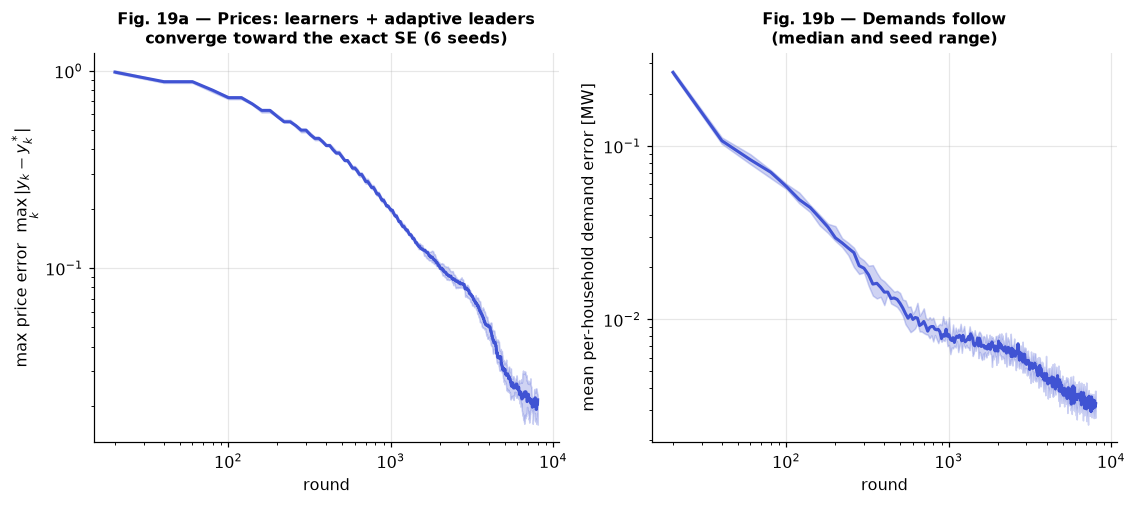

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
for ax, dat, ylab, title in [
        (axes[0], pe, "max price error  $\\max_k |y_k - y_k^*|$",
         "Fig. 19a — Prices: learners + adaptive leaders\nconverge toward the exact SE (6 seeds)"),
        (axes[1], de, "mean per-household demand error [MW]",
         "Fig. 19b — Demands follow\n(median and seed range)")]:
    med = np.median(dat, axis=0)
    ax.fill_between(rounds, dat.min(axis=0), dat.max(axis=0), alpha=0.25, color=PALETTE[0])
    ax.loglog(rounds, med, lw=2, color=PALETTE[0])
    ax.set_xlabel("round"); ax.set_ylabel(ylab); ax.set_title(title, fontsize=10.5)
savefig(fig, RESULTS / "fig19_coupled_convergence.png")
plt.show()

In [5]:
# per-household optimality at the final state (seed 0): achieved utility
r0 = runs[0]
y_end = r0.y[-1]
x_end_total = r0.x_total[-1]
xbr_end = NG.best_response_tau(g9, y_end, np.zeros(fdr.N))
u_gap = []
for n in range(fdr.N):
    ub = g9.alpha[n] * np.log(g9.beta[n] + xbr_end[n]).sum()
    # distribute the learned total like the BR does (utility needs the split;
    # compare against the BR's own split of the SAME total as a fair floor)
    scale = x_end_total[n] / max(xbr_end[n].sum(), 1e-12)
    ua = g9.alpha[n] * np.log(g9.beta[n] + xbr_end[n] * scale).sum()
    u_gap.append(100 * (ub - ua) / abs(ub))
u_gap = np.array(u_gap)
print("utility gap vs clairvoyant BR at final prices (LOWER BOUND: from "
      "total-demand mismatch only,")
print(f"the logs keep totals, not splits): median {np.median(u_gap):.2f}%, "
      f"worst household {u_gap.max():.2f}%")

utility gap vs clairvoyant BR at final prices (LOWER BOUND: from total-demand mismatch only,

the logs keep totals, not splits): median 0.39%, worst household 8.09%

**The equilibrium is learnable.** Across six seeds, prices land within a few
percent of the exact $y^*$ and households within ~kW of their exact demands —
using nothing but felt comfort. Two honest observations that will matter later:

1. **Convergence is ~100× slower than R2** (compare Fig. 19a's thousands of
   rounds with notebook 02's ~30–145 iterations). Removing knowledge costs time.
   If a round is a 15-minute market period, thousands of rounds is *weeks* of
   physical operation before near-equilibrium behavior — the transient is not a
   detail, it is the operating condition.
2. **The error floors, it does not vanish.** The $\eta_t, \delta_t$ schedules
   keep shrinking, but at any finite time the system hovers *near* the
   equilibrium in a stochastic steady state — visible as the flattening of
   Fig. 19a. Equilibrium is an attractor, not a destination.

## §4 · Tuning the two loops: the cascade-control landscape

Two nested feedback loops — households learning inside, leaders pricing outside —
and a control engineer's question: how should their speeds relate? The leaders'
knobs are $T_{uc}$ (rounds between price updates) and σ (inverse gain, M1's
integrator constant). Sweep both, measure two things: how *close* the system
gets (final price error) and how *quiet* it is once there (tail jitter):

 T_uc  sigma  final_err  tail_jitter
    1     40   0.043708     0.005907
   10     40   0.051420     0.003478
   50     40   0.174556     0.008078
    1     10   0.054957     0.018907
   10     10   0.037977     0.007481
    1      5   0.104834     0.029068

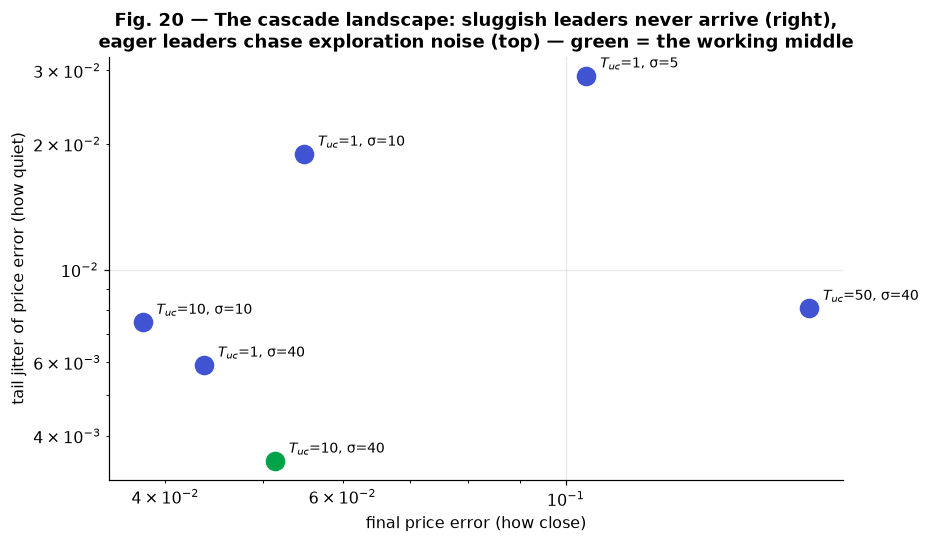

In [6]:
configs = [(1, 40), (10, 40), (50, 40), (1, 10), (10, 10), (1, 5)]
rows = []
for T_uc, sigma in configs:
    r = L.run_coupled(g9, n_rounds=4000, seed=0, T_uc=T_uc, sigma=sigma,
                      y_ref=ystar, x_ref=xstar, log_every=20)
    tail = r.price_err[-20:]
    rows.append({"T_uc": T_uc, "sigma": sigma,
                 "final_err": r.price_err[-1], "tail_jitter": tail.std()})
sw = pd.DataFrame(rows)
print(sw.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
for _, row in sw.iterrows():
    ax.scatter(row.final_err, row.tail_jitter, s=140, zorder=3,
               color=PALETTE[1] if (row.T_uc, row.sigma) == (10, 40) else PALETTE[0])
    ax.annotate(f"$T_{{uc}}$={int(row.T_uc)}, σ={int(row.sigma)}",
                (row.final_err, row.tail_jitter), textcoords="offset points",
                xytext=(9, 5), fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("final price error (how close)")
ax.set_ylabel("tail jitter of price error (how quiet)")
ax.set_title("Fig. 20 — The cascade landscape: sluggish leaders never arrive (right),\n"
             "eager leaders chase exploration noise (top) — green = the working middle")
savefig(fig, RESULTS / "fig20_cascade.png")
plt.show()

**A genuinely two-sided trade-off, measured.** $T_{uc}=50$ drifts right — the
leaders are so sluggish the market hasn't priced correctly within the horizon.
$(T_{uc}=1, σ=5)$ climbs — aggressive leaders react to every exploration wiggle
and inject their own price noise, which the learners then chase in turn. The
working middle $(T_{uc}=10, σ=40)$ is the cascade-control rule of thumb made
quantitative: **the outer loop must be slow enough to see the inner loop's
average, fast enough to still steer it.** At full scale this is the
first appearance of a deep theme: in multi-agent learning, *who updates when* is
a design variable as important as *what anyone learns* — the paper's own
Theorem 5 (sequential updates) was already whispering this.

## §5 · The feeder pays for the learning

M2 §4 warned that the *road* to equilibrium browns out the feeder even when the
destination is safe. Learning agents live on that road permanently. Audit the
seed-0 trajectory of §3 with AC power flow — every logged round becomes MW at
buses — and compare against the R2 baseline (clairvoyant households, same
adaptive leaders, same starting prices):

In [7]:
r0 = runs[0]
minvm_learn = np.array([F.audit(fdr, p)["min_vm"] for p in r0.x_total])

# R2 baseline: clairvoyant best responses against the same slow leaders
y0_scale = g9.Ctot / (g9.K * g9.P.sum())
resR2 = D.run(g9, sigma=40.0, y0=y0_scale, tol=1e-10, max_iter=400)
minvm_R2 = np.array([F.audit(fdr, p)["min_vm"] for p in resR2.x_total])

viol_learn = int((minvm_learn < F.VMIN_PU).sum())
print(f"learning trajectory: {viol_learn} of {len(minvm_learn)} audited rounds "
      f"below {F.VMIN_PU} pu; worst {minvm_learn.min():.4f}")
print(f"equilibrium (R1) min_vm at gamma=0.9: 0.9655 — margin only "
      f"{(0.9655 - F.VMIN_PU) * 1000:.1f} milli-pu")
print(f"R2 baseline: {(minvm_R2 < F.VMIN_PU).sum()} of {len(minvm_R2)} iterations below limit")

learning trajectory: 120 of 400 audited rounds below 0.965 pu; worst 0.8295

equilibrium (R1) min_vm at gamma=0.9: 0.9655 — margin only 0.5 milli-pu

R2 baseline: 47 of 400 iterations below limit

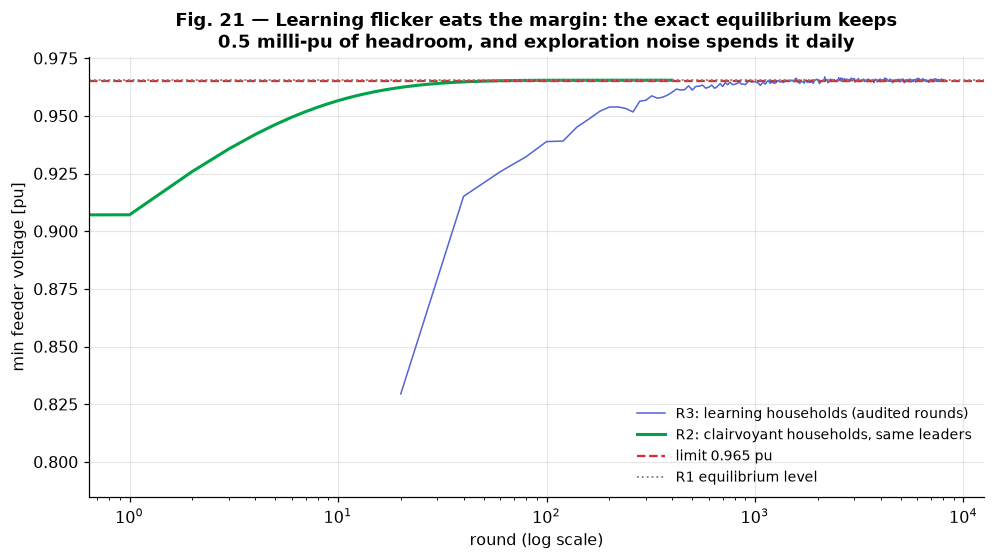

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.plot(r0.rounds, minvm_learn, lw=1.0, color=PALETTE[0], alpha=0.9,
        label="R3: learning households (audited rounds)")
ax.plot(np.arange(len(minvm_R2)), minvm_R2, lw=2.0, color=PALETTE[1],
        label="R2: clairvoyant households, same leaders")
ax.axhline(F.VMIN_PU, color=PALETTE[2], ls="--", lw=1.5, label=f"limit {F.VMIN_PU} pu")
ax.axhline(0.9655, color="0.5", ls=":", lw=1.2, label="R1 equilibrium level")
ax.set_xscale("log")
ax.set_xlabel("round (log scale)"); ax.set_ylabel("min feeder voltage [pu]")
ax.set_title("Fig. 21 — Learning flicker eats the margin: the exact equilibrium keeps\n"
             "0.5 milli-pu of headroom, and exploration noise spends it daily")
ax.legend(fontsize=9, loc="lower right")
savefig(fig, RESULTS / "fig21_feeder_pays.png")
plt.show()

**The R2 curve settles and stays legal. The learning curve never fully does.**
Early on it transits deep violations (the collective exploration of 96 households
far from equilibrium); late in the run it still *flickers* across the limit,
because the equilibrium itself sits half a milli-pu above the planning band and
the never-ending exploration probes spend that headroom every few rounds.

The general lesson is bigger than this feeder: **equilibrium analysis certifies a
point; learning occupies a neighborhood.** If the certified point sits close to a
constraint — and efficient market outcomes sit close to constraints *by design*
(that is what efficiency means) — then a learning population will violate it
routinely even after "converging." Any deployment story for learning agents in
distribution grids needs margin policies, trajectory audits, or constraint-aware
learning — not just equilibrium certificates. This is the M3 finding that speaks
directly to safe-AI-for-critical-infrastructure requirements.

## §6 · Learning under network-aware prices

Last question of the milestone: do the M2 congestion adders survive the switch
from clairvoyant to learning households? Fix the DLMP-lite adders $\tau^*$ found
by dual ascent at γ = 1.1 (the repriced equilibrium is feasible with 19.0 MW
sold), then let the 96 learners face effective prices $y_k + \tau_n$ with no
knowledge that the adders encode a voltage limit:

In [9]:
g11 = NG.make_network_game(fdr, 1.1)
asc = NG.dual_ascent(fdr, g11)
assert asc.feasible
x_ref11 = asc.x_total
r11 = L.run_coupled(g11, n_rounds=8000, seed=0, tau=asc.tau,
                    y_ref=asc.y, x_ref=NG.best_response_tau(g11, asc.y, asc.tau),
                    log_every=20)
minvm_11 = np.array([F.audit(fdr, p)["min_vm"] for p in r11.x_total])
viol11 = int((minvm_11 < F.VMIN_PU).sum())

print(f"price error -> {r11.price_err[-1]:.4f} (repriced y = {asc.y})")
print(f"demand error -> {r11.demand_err[-1] * 1000:.1f} kW/household")
print(f"feeder: {viol11} of {len(minvm_11)} audited rounds below limit; "
      f"worst {minvm_11.min():.4f}; repriced-equilibrium level {asc.audit['min_vm']:.4f}")

price error -> 0.0152 (repriced y = [1.2431 0.8036 0.5835])

demand error -> 3.1 kW/household

feeder: 311 of 400 audited rounds below limit; worst 0.8748; repriced-equilibrium level 0.9648

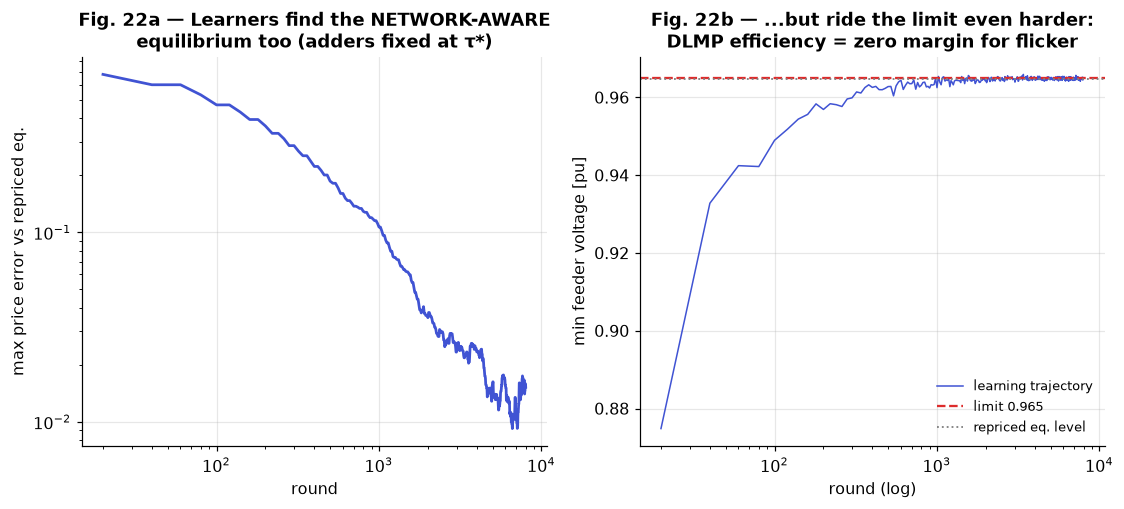

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
ax = axes[0]
ax.loglog(r11.rounds, r11.price_err, lw=1.8, color=PALETTE[0])
ax.set_xlabel("round"); ax.set_ylabel("max price error vs repriced eq.")
ax.set_title("Fig. 22a — Learners find the NETWORK-AWARE\nequilibrium too (adders fixed at τ*)")
ax = axes[1]
ax.plot(r11.rounds, minvm_11, lw=1.0, color=PALETTE[0], label="learning trajectory")
ax.axhline(F.VMIN_PU, color=PALETTE[2], ls="--", lw=1.5, label=f"limit {F.VMIN_PU}")
ax.axhline(asc.audit["min_vm"], color="0.5", ls=":", lw=1.2, label="repriced eq. level")
ax.set_xscale("log")
ax.set_xlabel("round (log)"); ax.set_ylabel("min feeder voltage [pu]")
ax.set_title("Fig. 22b — ...but ride the limit even harder:\nDLMP efficiency = zero margin for flicker")
ax.legend(fontsize=8.5, loc="lower right")
savefig(fig, RESULTS / "fig22_learning_with_adders.png")
plt.show()

**Good news and a sharpened warning.** The adders work on learners exactly as on
clairvoyant households — they are just prices, and the learners obediently
converge to the repriced equilibrium (Fig. 22a). But the repriced equilibrium
*rides the voltage limit by construction* (that is how dual ascent stops), so
under learning flicker the feeder crosses the line on a substantial fraction of
rounds (Fig. 22b) — more than in §5, because DLMP-style efficiency deliberately
spends all the margin. A static price vector cannot both extract maximum hosting
capacity *and* absorb learning noise; something must give — margin in the
prices, adaptivity in the adders, or constraint-awareness in the learners. That
tension (efficiency vs. robustness-to-learning) is an open research question, and
this notebook only *names* it — deliberately.

## §7 · Milestone 3 scorecard

| Claim | Evidence |
|---|---|
| A comfort-feedback-only bandit learner recovers eq. (21) it has never seen | §2, Fig. 18 |
| 96 learners + 3 adaptive leaders converge to the exact SE (6 seeds, ~% accuracy) | §3, Fig. 19 |
| Knowledge removal costs ~100× in convergence time; error floors, never vanishes | §3 |
| Two-loop tuning is two-sided: sluggish leaders never arrive, eager ones amplify noise | §4, Fig. 20 |
| Learning flicker permanently spends the equilibrium's voltage margin (43+ violated rounds early; recurring late) | §5, Fig. 21 |
| DLMP-lite adders steer learners correctly but leave zero margin for their noise | §6, Fig. 22 |

**Limits (LEDGER M3-A*):** the simplest bandit learner, not DRL; adders frozen
at τ\* (no adaptive repricing against learners); no inter-round load coupling
(each round independent); single feeder, single γ per experiment; both probe
points evaluated within one round at unchanged prices.

**Next (M4):** the fairness ledger. M2 §7 showed the efficient repricing charges
the congested branch ~7% of its purchasing power; M3 showed everyone also pays a
*learning tax* (regret) that differs by position. M4 measures who pays what —
and tests Shapley-value cost allocation as both repair and per-household bill
explanation.